# Wave 1 Demographic Overview

This notebook gives a compact demographic snapshot of the **Wave 1** respondents in the HCMST dataset.

To keep the overview clear and easy to present, we focus on six core variables:

- age category
- gender
- education
- race / ethnicity
- household income
- region

The notebook now does two main things:

- profile the Wave 1 sample overall
- compare the demographic profile of respondents in different-sex and same-sex couples

The goal here is descriptive rather than causal. We are summarising who appears in the sample, not explaining why the sample looks this way.

## 1. Setup

We load the Wave 1 demographic columns and one grouping variable for couple type.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")
df.shape

/tmp/ipykernel_43012/2387549003.py:8: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")


(3510, 725)

## 2. Select the Demographic Columns

These six variables are broad, interpretable, and well suited to a first-pass demographic overview. We also include `w1_same_sex_couple` as the subgroup flag for comparison.

In [3]:
demo_cols = [
    "w1_ppagecat",
    "w1_ppgender",
    "w1_ppeducat",
    "w1_ppethm",
    "w1_ppincimp_cat",
    "w1_PPREG4",
]

group_col = "w1_same_sex_couple"

demo_labels = {
    "w1_ppagecat": "Age category",
    "w1_ppgender": "Gender",
    "w1_ppeducat": "Education",
    "w1_ppethm": "Race / ethnicity",
    "w1_ppincimp_cat": "Household income",
    "w1_PPREG4": "Region",
}

couple_type_labels = {
    0: "Different-sex couple",
    1: "Same-sex couple",
    "different_sex_couple": "Different-sex couple",
    "same_sex_couple": "Same-sex couple",
    "Different-sex couple": "Different-sex couple",
    "Same-sex couple": "Same-sex couple",
}

df_demo = df[demo_cols + [group_col]].copy()
df_demo[group_col] = df_demo[group_col].astype("string").replace(couple_type_labels)
df_demo.head()

,w1_ppagecat,w1_ppgender,w1_ppeducat,w1_ppethm,w1_ppincimp_cat,w1_PPREG4,w1_same_sex_couple
0,45-54,Female,High school,"2+ Races, Non-Hispanic",$40K-$75K,Midwest,NOT same-sex souple
1,65-74,Female,Some college,"White, Non-Hispanic",$40K-$75K,West,NOT same-sex souple
2,35-44,Male,Some college,"White, Non-Hispanic",$75K-$125K,West,NOT same-sex souple
3,45-54,Male,High school,"White, Non-Hispanic",$75K-$125K,Northeast,NOT same-sex souple
4,45-54,Male,Some college,"White, Non-Hispanic",$75K-$125K,West,NOT same-sex souple


## 3. Coverage and Missingness

Before describing the sample, it helps to see whether these fields are broadly available.

In [4]:
coverage = pd.DataFrame({
    "label": [demo_labels[col] for col in demo_cols] + ["Couple type"],
    "non_missing": [df_demo[col].notna().sum() for col in demo_cols + [group_col]],
    "missing": [df_demo[col].isna().sum() for col in demo_cols + [group_col]],
    "missing_pct": [round(df_demo[col].isna().mean() * 100, 2) for col in demo_cols + [group_col]],
}, index=demo_cols + [group_col])

coverage

,label,non_missing,missing,missing_pct
w1_ppagecat,Age category,3510,0,0.0
w1_ppgender,Gender,3510,0,0.0
w1_ppeducat,Education,3510,0,0.0
w1_ppethm,Race / ethnicity,3510,0,0.0
w1_ppincimp_cat,Household income,3510,0,0.0
w1_PPREG4,Region,3510,0,0.0
w1_same_sex_couple,Couple type,3394,116,3.3


## 4. Overall Frequency Tables

For each variable, we display counts and percentages for the full Wave 1 sample.

In [5]:
def frequency_table(series):
    counts = series.value_counts(dropna=False)
    pct = (series.value_counts(dropna=False, normalize=True) * 100).round(2)
    out = pd.DataFrame({"count": counts, "percent": pct})
    out.index.name = series.name
    return out

for col in demo_cols:
    print("\n" + "=" * 80)
    print(demo_labels[col])
    display(frequency_table(df_demo[col]))


Age category


,count,percent
w1_ppagecat,,
55-64,796,22.68
25-34,661,18.83
45-54,568,16.18
35-44,544,15.50
65-74,489,13.93
18-24,254,7.24
75+,198,5.64



Gender


,count,percent
w1_ppgender,,
Female,1764,50.26
Male,1746,49.74



Education


...

,count,percent
w1_ppethm,,
"White, Non-Hispanic",2503,71.31
Hispanic,438,12.48
"Black, Non-Hispanic",311,8.86
"Other, Non-Hispanic",147,4.19
"2+ Races, Non-Hispanic",111,3.16



Household income


,count,percent
w1_ppincimp_cat,,
<$40K,1001,28.52
$75K-$125K,876,24.96
$40K-$75K,848,24.16
>$125K,785,22.36



Region


,count,percent
w1_PPREG4,,
South,1268,36.13
West,831,23.68
Midwest,770,21.94
Northeast,641,18.26


## 5. Overall Visual Overview

These bar charts give a quick visual summary of the full-sample distributions.

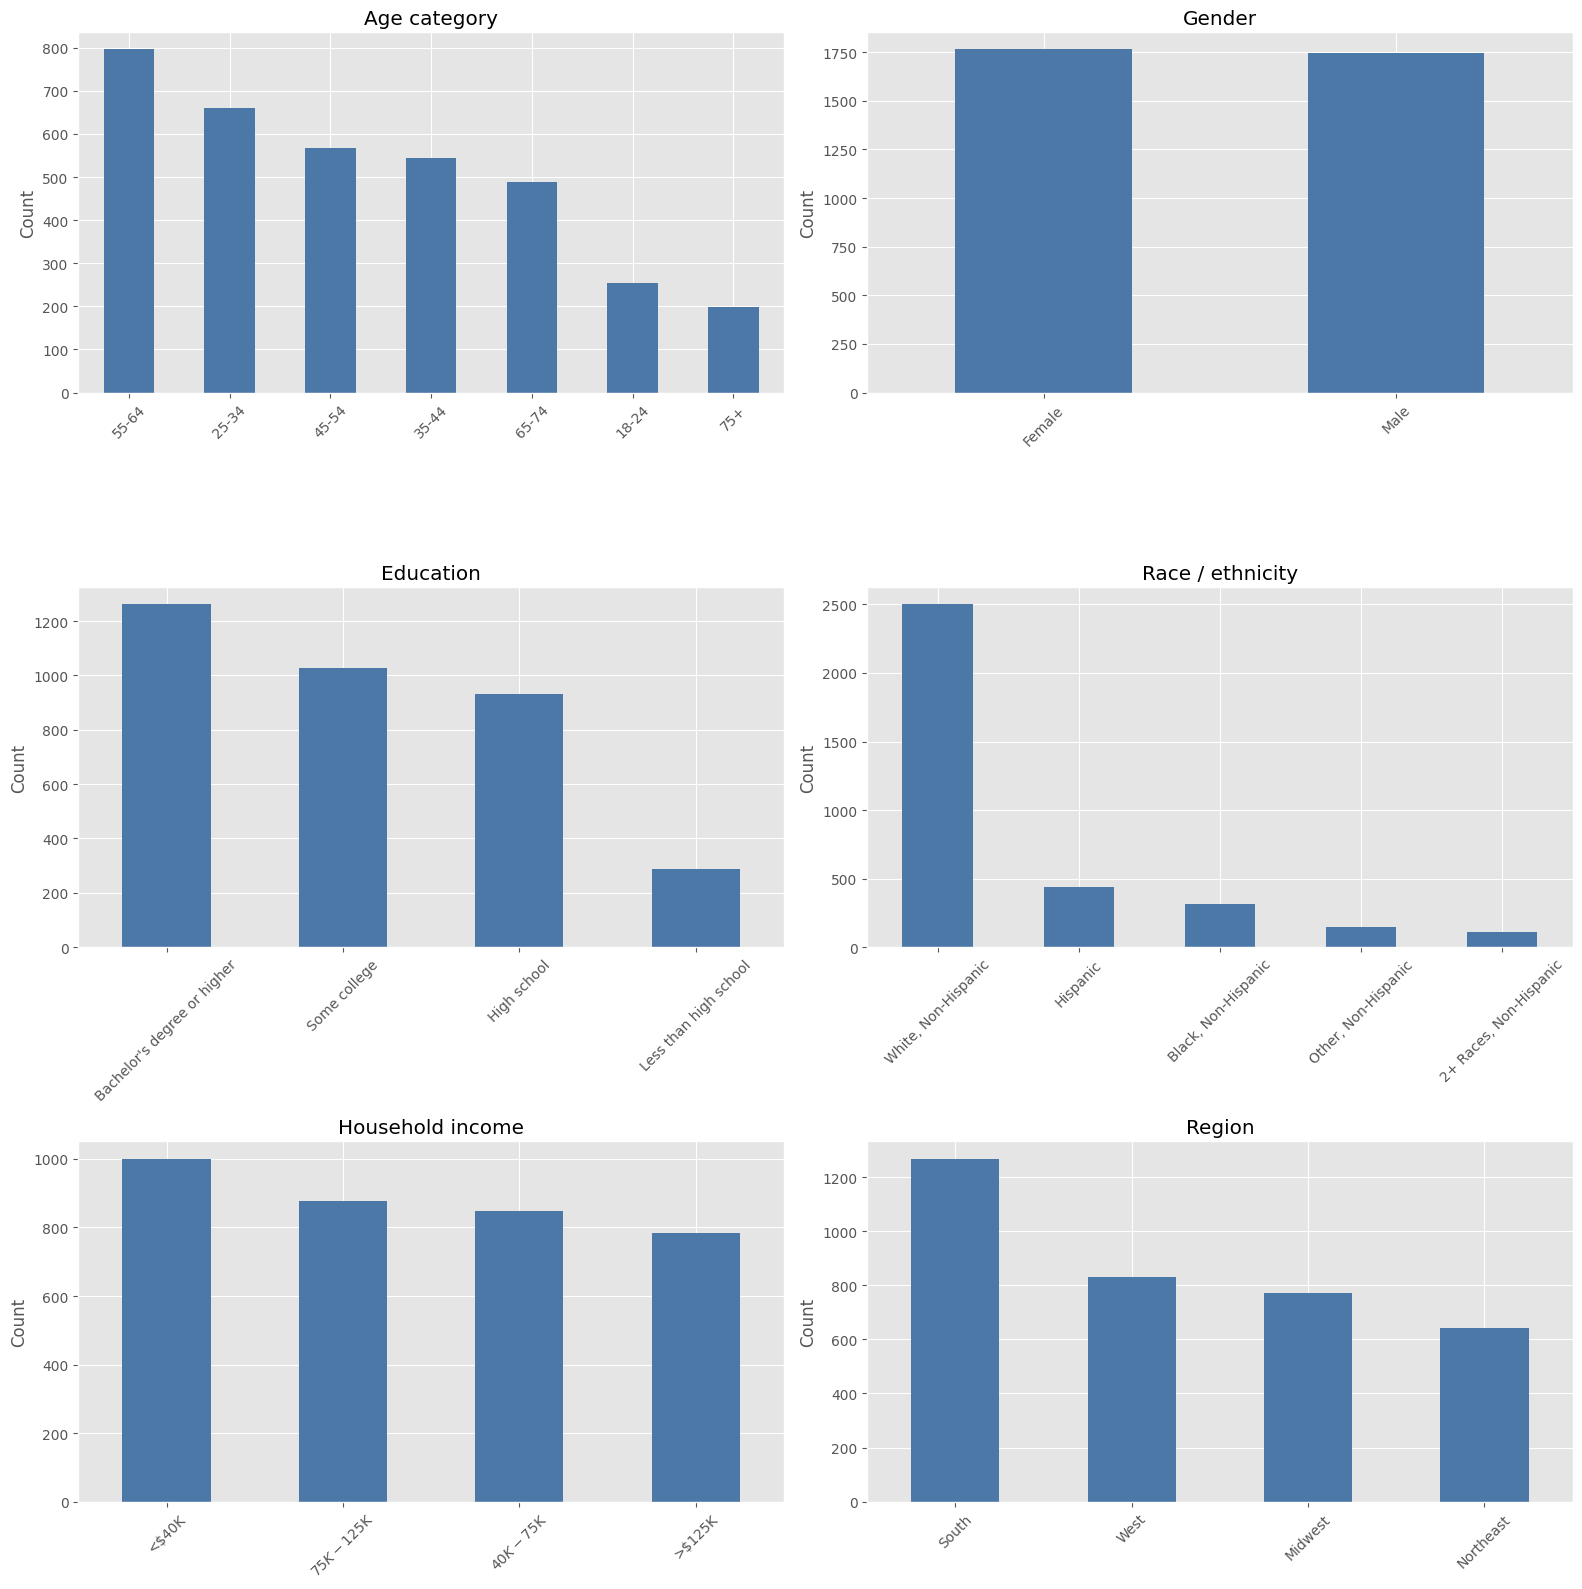

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, col in zip(axes, demo_cols):
    counts = df_demo[col].value_counts(dropna=False)
    counts.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(demo_labels[col])
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Couple-Type Split

Before comparing demographics, we first check how many respondents fall into each couple-type group.

In [7]:
frequency_table(df_demo[group_col])

,count,percent
w1_same_sex_couple,,
NOT same-sex souple,3086,87.92
Same-sex couple,308,8.77
<NA>,116,3.3


## 7. Demographic Comparison by Couple Type

For each variable, we compare the within-group percentage distribution for respondents in different-sex and same-sex couples.

In [8]:
def group_percent_table(df_in, col, group_col):
    table = pd.crosstab(df_in[col], df_in[group_col], normalize="columns") * 100
    return table.round(2)

for col in demo_cols:
    print("\n" + "=" * 80)
    print(demo_labels[col])
    display(group_percent_table(df_demo.dropna(subset=[group_col]), col, group_col))


Age category


w1_same_sex_couple,NOT same-sex souple,Same-sex couple
w1_ppagecat,,
18-24,5.93,6.82
25-34,17.98,23.05
35-44,15.65,16.23
45-54,16.10,22.40
55-64,23.36,21.43
65-74,14.91,7.14
75+,6.06,2.92



Gender


w1_same_sex_couple,NOT same-sex souple,Same-sex couple
w1_ppgender,,
Male,47.99,62.01
Female,52.01,37.99



Education


...

w1_same_sex_couple,NOT same-sex souple,Same-sex couple
w1_ppethm,,
"White, Non-Hispanic",71.78,70.45
"Black, Non-Hispanic",9.14,5.84
"Other, Non-Hispanic",4.08,3.57
Hispanic,11.86,18.51
"2+ Races, Non-Hispanic",3.14,1.62



Household income


w1_same_sex_couple,NOT same-sex souple,Same-sex couple
w1_ppincimp_cat,,
<$40K,27.64,32.79
$40K-$75K,24.34,21.75
$75K-$125K,25.41,23.38
>$125K,22.62,22.08



Region


w1_same_sex_couple,NOT same-sex souple,Same-sex couple
w1_PPREG4,,
Northeast,18.60,16.56
Midwest,21.71,21.75
South,36.78,30.52
West,22.91,31.17


## 8. Comparison Plots

These charts show the same comparison visually, using percentages within each couple-type group.

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, col in zip(axes, demo_cols):
    plot_df = pd.crosstab(df_demo[col], df_demo[group_col], normalize="columns") * 100
    plot_df = plot_df.round(2)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(demo_labels[col])
    ax.set_xlabel("")
    ax.set_ylabel("Percent within couple type")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 9. Complete-Case Snapshot

This shows how many respondents have non-missing values for all six demographic variables and the couple-type flag together.

In [ ]:
complete_cases = df_demo.dropna().copy()

print("Rows in full dataset:", len(df_demo))
print("Rows with all 6 demographic variables and couple type present:", len(complete_cases))
print("Complete-case share (%):", round(len(complete_cases) / len(df_demo) * 100, 2))

## 10. Takeaway

This notebook now supports two useful descriptive tasks:

- describing the Wave 1 sample overall
- comparing demographic profiles for respondents in different-sex and same-sex couples

That makes it a solid introductory notebook before moving into relationship outcomes or stability analyses.